In [1]:
# Step 1: Libraries install karo
!pip install tensorflow opencv-python matplotlib numpy pillow

In [2]:
# Step 2: Kaggle dataset download karo
!pip install kaggle

import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [4]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

token = '{"username":"khananamitchaudhari","key":"KGAT_5fb0d6785a71ca49c31dc4253fd8c3b0"}'

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(token)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle token set ho gaya!")

Kaggle token set ho gaya!


In [5]:
# Step 4: FER2013 Dataset download karo
!kaggle datasets download -d msambare/fer2013
!unzip fer2013.zip -d dataset
print("Dataset ready hai!")

Streaming output truncated to the last 5000 lines.
  inflating: dataset/train/sad/Training_65267116.jpg  
  inflating: dataset/train/sad/Training_65275626.jpg  
  inflating: dataset/train/sad/Training_6529266.jpg  
  inflating: dataset/train/sad/Training_65329617.jpg  
  inflating: dataset/train/sad/Training_65338712.jpg  
  inflating: dataset/train/sad/Training_65338797.jpg  
  inflating: dataset/train/sad/Training_65387162.jpg  
  inflating: dataset/train/sad/Training_65404494.jpg  
  inflating: dataset/train/sad/Training_65426218.jpg  
  inflating: dataset/train/sad/Training_65430136.jpg  
  inflating: dataset/train/sad/Training_65437377.jpg  
  inflating: dataset/train/sad/Training_6545735.jpg  
  inflating: dataset/train/sad/Training_65463385.jpg  
  inflating: dataset/train/sad/Training_65473985.jpg  
  inflating: dataset/train/sad/Training_65502829.jpg  
  inflating: dataset/train/sad/Training_65505359.jpg  
  inflating: dataset/train/sad/Training_65508578.jpg  
  inflating: dat

In [6]:
# Step 5: Model Training
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data load karo
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)
test_data = test_datagen.flow_from_directory(
    'dataset/test',
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

# CNN Model banao
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("Model ready hai - training shuru hogi!")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,911 (2.36 MB)

 Trainable params: 619,463 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

Model ready hai - training shuru hogi!


In [7]:
# Step 6: Model train karo
history = model.fit(
    train_data,
    epochs=30,
    validation_data=test_data,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
)

# Model save karo
model.save('emotion_model.h5')
print("Model train ho gaya aur save ho gaya!")

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 44s 72ms/step - accuracy: 0.2590 - loss: 1.8583 - val_accuracy: 0.3015 - val_loss: 1.8202 - learning_rate: 0.0010
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.3211 - loss: 1.6956 - val_accuracy: 0.3916 - val_loss: 1.5694 - learning_rate: 0.0010
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.3568 - loss: 1.6247 - val_accuracy: 0.4257 - val_loss: 1.4704 - learning_rate: 0.0010
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.3799 - loss: 1.5828 - val_accuracy: 0.4156 - val_loss: 1.4499 - learning_rate: 0.0010
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.4009 - loss: 1.5286 - val_accuracy: 0.4362 - val_loss: 1.5052 - learning_rate: 0.0010
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - accuracy: 0.4110 - loss: 1.5040 - val_accuracy: 0.4843 - val_loss: 1.3402 - learning_rate: 0.0010
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.4252 - l

Model train ho gaya aur save ho gaya!


In [8]:
# Step 7: Google Drive mein save karo
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('emotion_model.h5', '/content/drive/MyDrive/emotion_model.h5')
shutil.copy('best_model.h5', '/content/drive/MyDrive/best_model.h5')
print("Model Drive mein save ho gaya - safe hai!")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: 'best_model.h5'

In [10]:
import shutil, os

# Pehle check karo files
print("Files:", os.listdir('/content'))

Files: ['.config', 'fer2013.zip', 'drive', 'emotion_model.h5', 'dataset', 'sample_data']


In [11]:
import shutil

shutil.copy('/content/emotion_model.h5', '/content/drive/MyDrive/emotion_model.h5')
print("Model Drive mein save ho gaya!")

Model Drive mein save ho gaya!


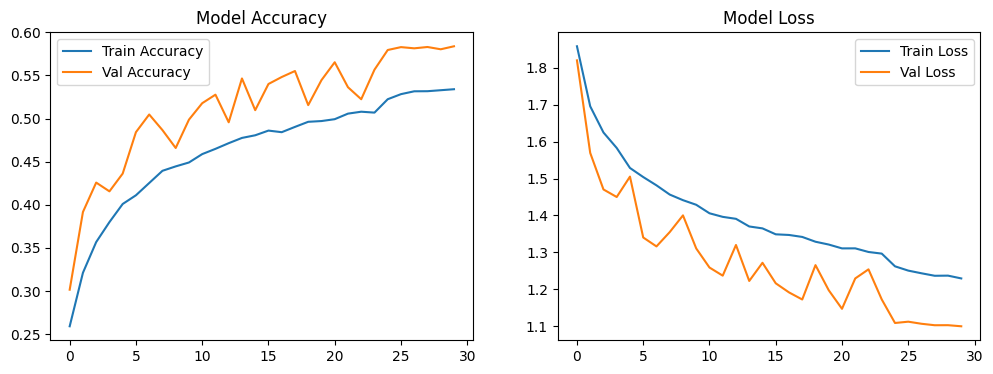

Graph save ho gaya!


In [12]:
# Step 8: Accuracy graph dekho
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.savefig('/content/drive/MyDrive/accuracy_graph.png')
plt.show()
print("Graph save ho gaya!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step


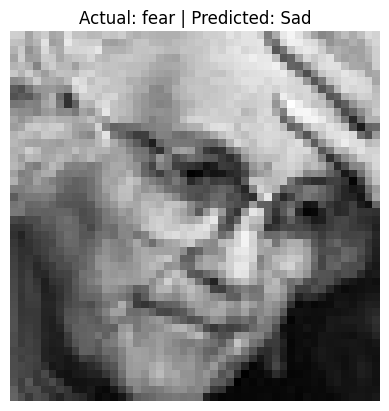

Actual emotion: fear
Predicted emotion: Sad
Confidence: 35%


In [13]:
# Step 9: Model test karo
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']

# Dataset se ek test image lo
import os
test_dir = '/content/dataset/test'
emotion_folder = os.listdir(test_dir)[0]
img_file = os.listdir(f'{test_dir}/{emotion_folder}')[0]
img_path = f'{test_dir}/{emotion_folder}/{img_file}'

# Predict karo
img = image.load_img(img_path, target_size=(48,48), color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0
img_array = img_array.reshape(1,48,48,1)

pred = model.predict(img_array)[0]
predicted = EMOTIONS[np.argmax(pred)]
actual = emotion_folder

# Show karo
plt.imshow(img, cmap='gray')
plt.title(f'Actual: {actual} | Predicted: {predicted}')
plt.axis('off')
plt.show()

print(f"Actual emotion: {actual}")
print(f"Predicted emotion: {predicted}")
print(f"Confidence: {int(np.max(pred)*100)}%")

In [14]:
# Step 10: Webcam se real-time detection
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Webcam se photo lo
js = Javascript('''
async function takePhoto() {
  const div = document.createElement('div');
  const video = document.createElement('video');
  video.style.display = 'block';
  const stream = await navigator.mediaDevices.getUserMedia({video: true});
  document.body.appendChild(div);
  div.appendChild(video);
  video.srcObject = stream;
  await video.play();
  await new Promise(resolve => setTimeout(resolve, 2000));
  const canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  canvas.getContext('2d').drawImage(video, 0, 0);
  stream.getTracks().forEach(track => track.stop());
  div.remove();
  return canvas.toDataURL('image/jpeg', 0.8);
}
''')
display(js)

# Photo lo aur predict karo
data = eval_js('takePhoto()')
binary = b64decode(data.split(',')[1])
img_array = np.frombuffer(binary, dtype=np.uint8)
frame = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
for (x,y,w,h) in faces:
    roi = gray[y:y+h, x:x+w]
    roi = cv2.resize(roi, (48,48)) / 255.0
    roi = roi.reshape(1,48,48,1)
    pred = model.predict(roi)[0]
    emotion = EMOTIONS[np.argmax(pred)]
    confidence = int(np.max(pred)*100)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame, f'{emotion} {confidence}%',(x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

# Result dikhao
import matplotlib.pyplot as plt
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title(f'Detected: {emotion} ({confidence}%)')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/webcam_result.png')
plt.show()
print(f"Emotion detected: {emotion} - {confidence}%")

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

Saving 20240511_225459.jpg to 20240511_225459.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step


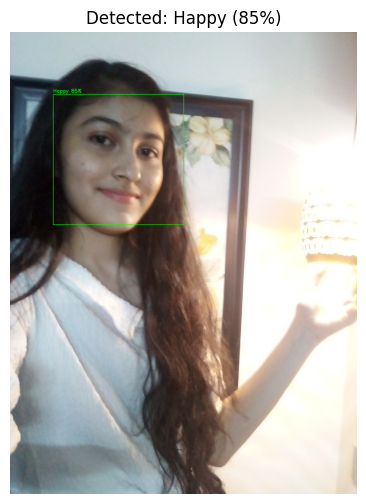

Emotion: Happy | Confidence: 85%


In [15]:
# Step 10: Apni photo upload karke test karo
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Photo upload karo
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict karo
frame = cv2.imread(img_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

emotion = "No face detected"
confidence = 0

for (x,y,w,h) in faces:
    roi = gray[y:y+h, x:x+w]
    roi = cv2.resize(roi, (48,48)) / 255.0
    roi = roi.reshape(1,48,48,1)
    pred = model.predict(roi)[0]
    emotion = EMOTIONS[np.argmax(pred)]
    confidence = int(np.max(pred)*100)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame, f'{emotion} {confidence}%',(x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title(f'Detected: {emotion} ({confidence}%)')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/result.png')
plt.show()
print(f"Emotion: {emotion} | Confidence: {confidence}%")

Saving WhatsApp Image 2026-06-13 at 12.11.19.jpeg to WhatsApp Image 2026-06-13 at 12.11.19.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step


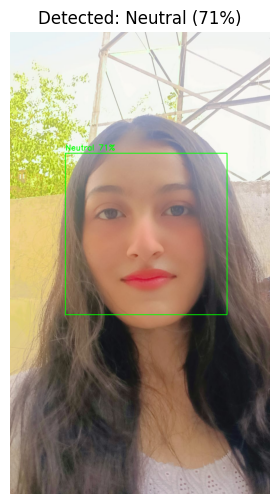

Emotion: Neutral | Confidence: 71%


In [17]:
# Step 10: Apni photo upload karke test karo
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Photo upload karo
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict karo
frame = cv2.imread(img_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

emotion = "No face detected"
confidence = 0

for (x,y,w,h) in faces:
    roi = gray[y:y+h, x:x+w]
    roi = cv2.resize(roi, (48,48)) / 255.0
    roi = roi.reshape(1,48,48,1)
    pred = model.predict(roi)[0]
    emotion = EMOTIONS[np.argmax(pred)]
    confidence = int(np.max(pred)*100)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame, f'{emotion} {confidence}%',(x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title(f'Detected: {emotion} ({confidence}%)')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/result.png')
plt.show()
print(f"Emotion: {emotion} | Confidence: {confidence}%")

Saving WhatsApp Image 2026-06-13 at 12.10.44.jpeg to WhatsApp Image 2026-06-13 at 12.10.44.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


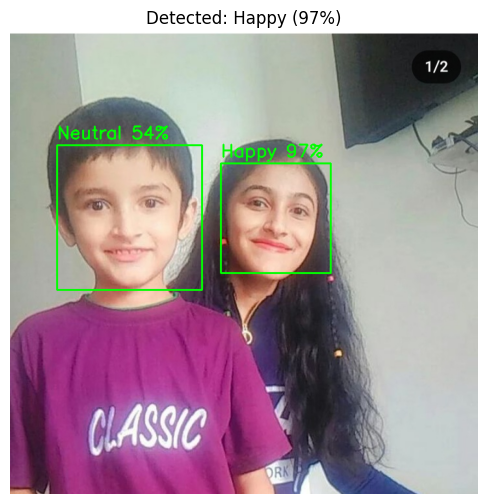

Emotion: Happy | Confidence: 97%


In [18]:
# Step 10: Apni photo upload karke test karo
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Photo upload karo
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict karo
frame = cv2.imread(img_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

emotion = "No face detected"
confidence = 0

for (x,y,w,h) in faces:
    roi = gray[y:y+h, x:x+w]
    roi = cv2.resize(roi, (48,48)) / 255.0
    roi = roi.reshape(1,48,48,1)
    pred = model.predict(roi)[0]
    emotion = EMOTIONS[np.argmax(pred)]
    confidence = int(np.max(pred)*100)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame, f'{emotion} {confidence}%',(x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title(f'Detected: {emotion} ({confidence}%)')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/result.png')
plt.show()
print(f"Emotion: {emotion} | Confidence: {confidence}%")

Saving WhatsApp Image 2026-06-13 at 12.10.44.jpeg to WhatsApp Image 2026-06-13 at 12.10.44 (1).jpeg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


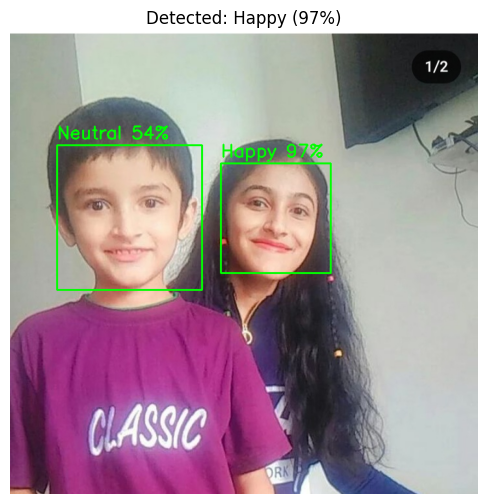

Emotion: Happy | Confidence: 97%


In [19]:
# Step 10: Apni photo upload karke test karo
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Photo upload karo
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict karo
frame = cv2.imread(img_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

emotion = "No face detected"
confidence = 0

for (x,y,w,h) in faces:
    roi = gray[y:y+h, x:x+w]
    roi = cv2.resize(roi, (48,48)) / 255.0
    roi = roi.reshape(1,48,48,1)
    pred = model.predict(roi)[0]
    emotion = EMOTIONS[np.argmax(pred)]
    confidence = int(np.max(pred)*100)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame, f'{emotion} {confidence}%',(x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title(f'Detected: {emotion} ({confidence}%)')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/result.png')
plt.show()
print(f"Emotion: {emotion} | Confidence: {confidence}%")

In [3]:
# Step 10: Apni photo upload karke test karo
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/emotion_model.h5')
EMOTIONS = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprised']
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Photo upload karo
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Predict karo
frame = cv2.imread(img_path)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

emotion = "No face detected"
confidence = 0

for (x,y,w,h) in faces:
    roi = gray[y:y+h, x:x+w]
    roi = cv2.resize(roi, (48,48)) / 255.0
    roi = roi.reshape(1,48,48,1)
    pred = model.predict(roi)[0]
    emotion = EMOTIONS[np.argmax(pred)]
    confidence = int(np.max(pred)*100)
    cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.putText(frame, f'{emotion} {confidence}%',(x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,255,0),2)

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,6))
plt.imshow(frame_rgb)
plt.title(f'Detected: {emotion} ({confidence}%)')
plt.axis('off')
plt.savefig('/content/drive/MyDrive/result.png')
plt.show()
print(f"Emotion: {emotion} | Confidence: {confidence}%")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/drive/MyDrive/emotion_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)